<center><font size=7><b>Stock Market Prediction Using News Sentiment Analysis</font></center>

<center><p float="center">
  <img src="https://d3twecw9qvot3u.cloudfront.net/wp-content/uploads/2018/03/ai-prediction-for-fintech-market.png" width="720"/>
</p></center>


## **Introduction**

### The stock market is influenced by various factors, especially financial news and market events. Investors often find it difficult to analyze a large number of news articles manually. Generative AI and Natural Language Processing (NLP) can automatically analyze financial news, identify sentiment, and classify it as positive or negative. This helps investors and analysts make faster and more informed decisions.

## **Problem Statement**

### Analyzing thousands of stock market news articles manually is time-consuming and inefficient. There is a need for an intelligent system that can automatically understand financial news and classify its sentiment to support better investment decisions.

## **objectives**

* To collect and preprocess stock market news data.
* To analyze financial news using Generative AI techniques.
* To classify news sentiment as Positive or Negative.
* To evaluate the model's performance using appropriate metrics.
* To provide insights that help investors understand market sentiment.

## **Business** **Context**

### The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

## **Problem Definition**

### With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

### As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

## **Data Dictionary**

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

## **Import Libraries**
### This step imports the required Python libraries for data manipulation, visualization.

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

### Mount the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### The stock_news.csv dataset is loaded into the DataFrame to begin the analysis.

In [ ]:
News = pd.read_csv("/content/drive/MyDrive/Gen AI-placement/stock_news.csv")

In [ ]:
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [ ]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [ ]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [ ]:
data.shape

(349, 8)

###**Checking for missing values**

In [ ]:
print(data.isnull().sum)

<bound method DataFrame.sum of       Date   News   Open   High    Low  Close  Volume  Label
0    False  False  False  False  False  False   False  False
1    False  False  False  False  False  False   False  False
2    False  False  False  False  False  False   False  False
3    False  False  False  False  False  False   False  False
4    False  False  False  False  False  False   False  False
..     ...    ...    ...    ...    ...    ...     ...    ...
344  False  False  False  False  False  False   False  False
345  False  False  False  False  False  False   False  False
346  False  False  False  False  False  False   False  False
347  False  False  False  False  False  False   False  False
348  False  False  False  False  False  False   False  False

[349 rows x 8 columns]>


### **Checking for duplicate values**

In [ ]:
duplicate_row = data.duplicated().sum()

In [ ]:
print(f"Number of duplicate rows: {(duplicate_row)}")

Number of duplicate rows: 0


## **Exploratory Data Analysis (EDA)**

### The data distribution and relationships are analyzed to understand the characteristics of the datase

### To display the structure of data

### This provides information about the dataset, including data types, number of entries, and missing values.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


### The 'Date' column is converted from object (text) format to datetime format. This allows the dataset to perform date-based analysis, sorting, filtering, and time-series operations accurately.

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


### This summarizes the statistical properties of numerical columns such as mean, standard deviation, minimum, and maximum values.

In [ ]:
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


## **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

## **Distribution of Sentiment polarity and all Numeric Variables**

### To display the distribution of sentiment labels in the dataset. It helps us understand how many news articles belong to each sentiment category (Negative, Neutral, and Positive).

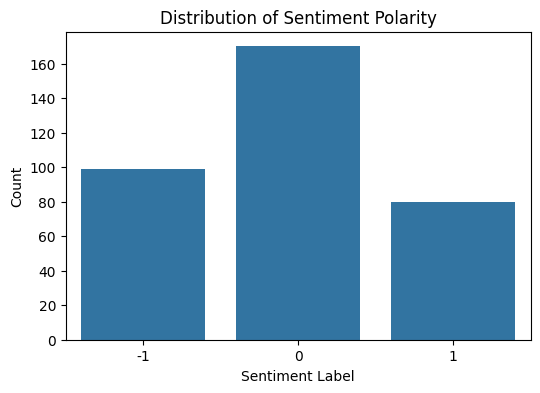

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

### Selects all numerical columns and plots a histogram for each feature. It helps analyze the distribution, frequency, and spread of numerical variables such as Open, High, Low, Close, and Volume.

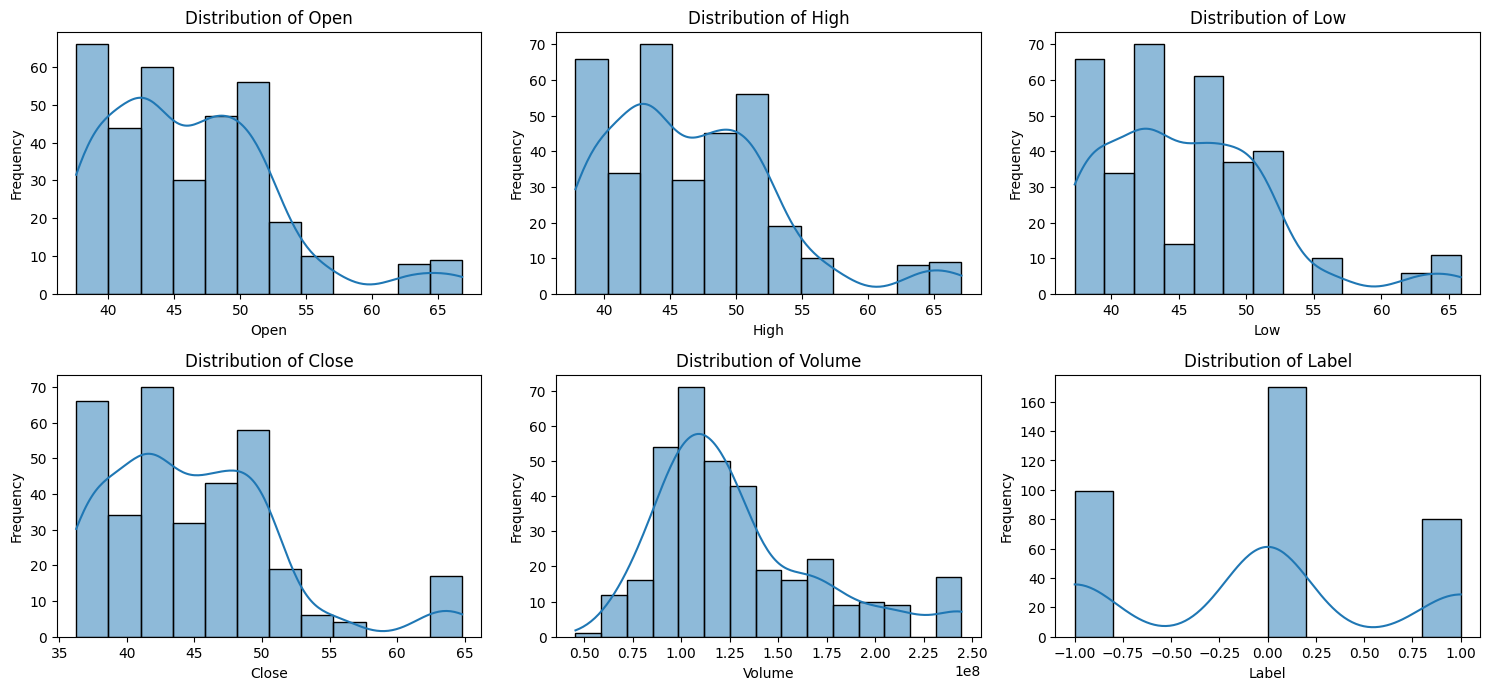

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

### The number of words in each news article and creates a new column . To summary statistics of the news length, including count, mean, minimum, maximum, and quartiles.

In [ ]:
data['news_length'] = data['News'].apply(lambda x: len(x.split()))

display(data['news_length'].describe())

,news_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


### Plot distribution

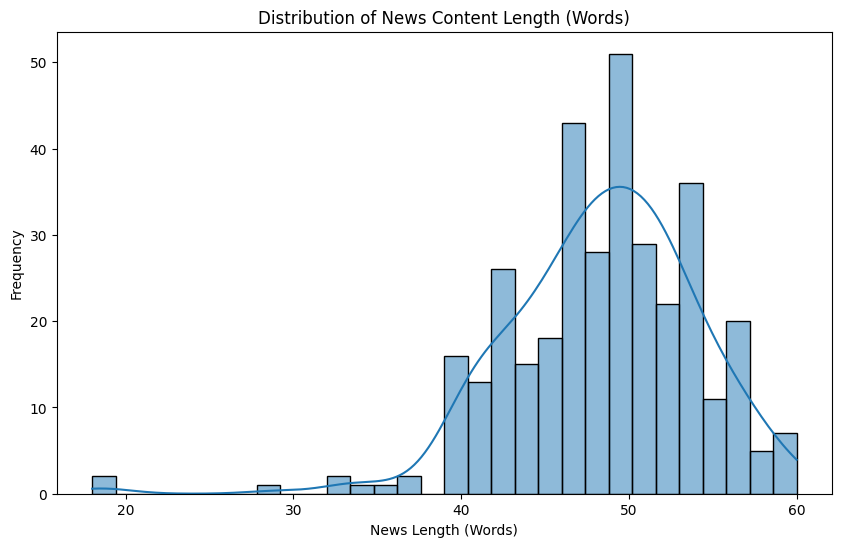

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['news_length'], kde=True, bins=30)
plt.title('Distribution of News Content Length (Words)')
plt.xlabel('News Length (Words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

### The Year and Month from the Date column and creates a new YearMonth column for monthly analysis and groups the dataset by month and calculates the average values of Open, High, Low, Close, and Volume.


In [ ]:
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


### The monthwise averages of all price variables for better visualization

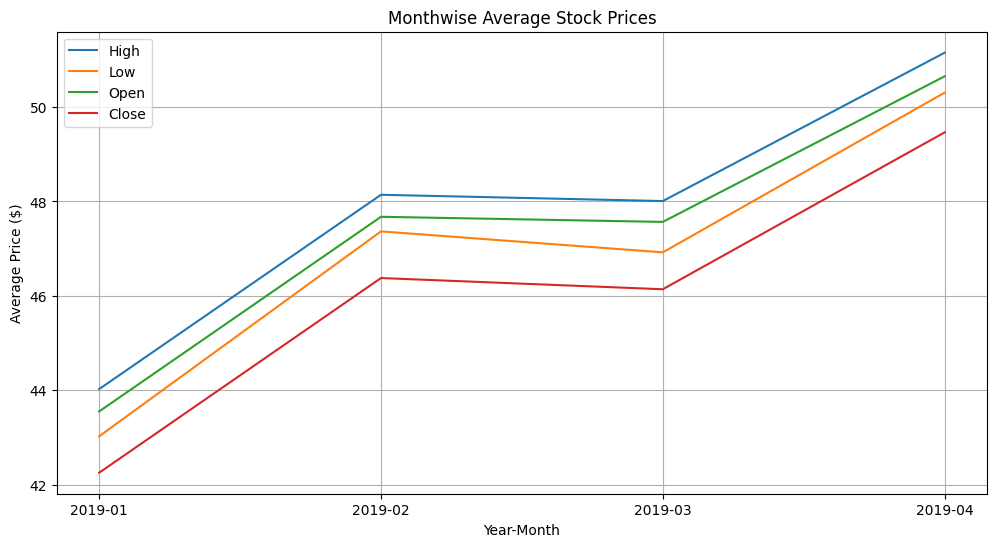

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(x='YearMonth', y='High', data=monthwise_avg, label='High')
sns.lineplot(x='YearMonth', y='Low', data=monthwise_avg, label='Low')
sns.lineplot(x='YearMonth', y='Open', data=monthwise_avg, label='Open')
sns.lineplot(x='YearMonth', y='Close', data=monthwise_avg, label='Close')

plt.title('Monthwise Average Stock Prices')
plt.xlabel('Year-Month')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True)
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

### It shows the trend of average trading volume across different months.

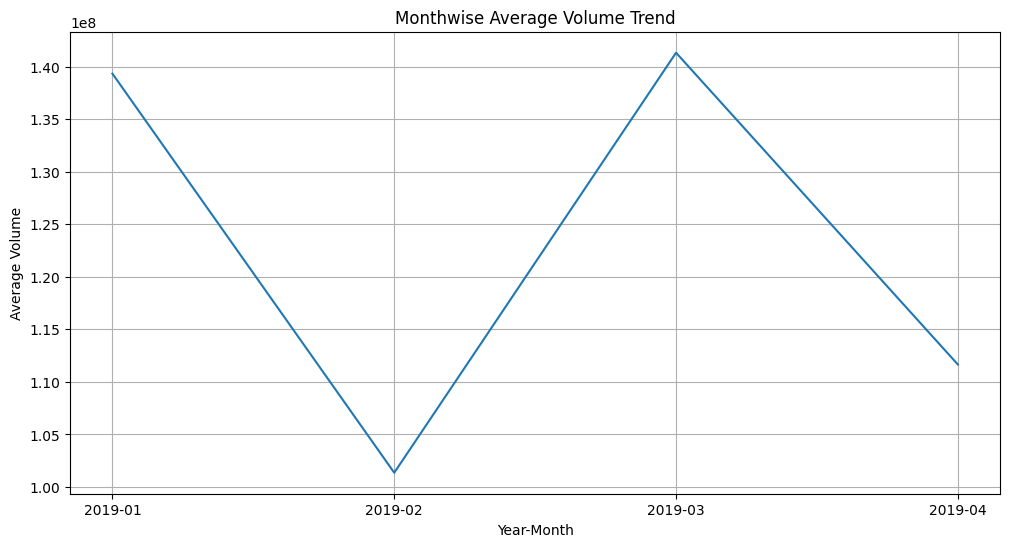

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg)
plt.title('Monthwise Average Volume Trend')
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.grid(True)
plt.show()

### This bar chart compares the average trading volume for each month, making it easier to identify the month with the highest and lowest trading activity.


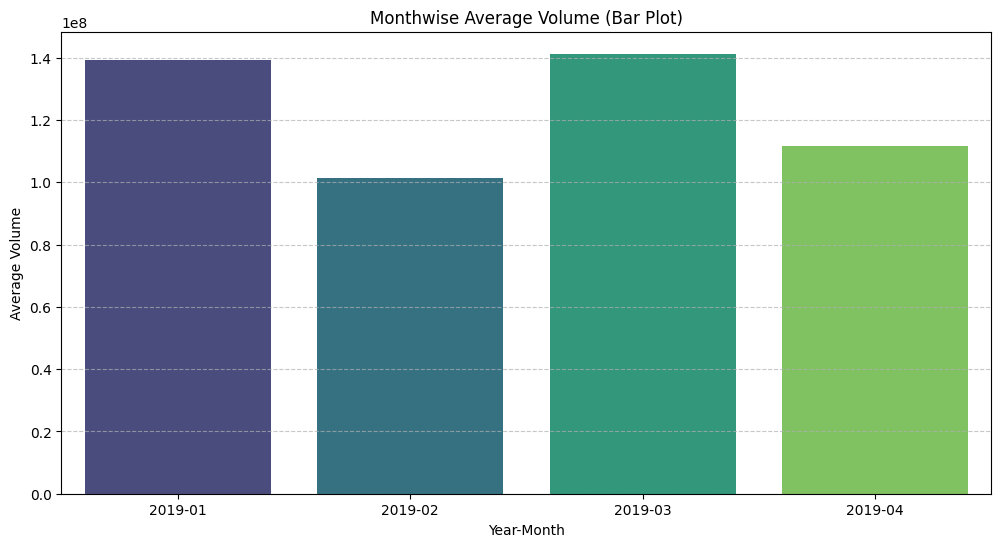

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Monthwise Average Volume (Bar Plot)')
plt.xlabel('Year-Month')
plt.ylabel('Average Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### All numerical variables to identify outliers and understand the spread of the data.

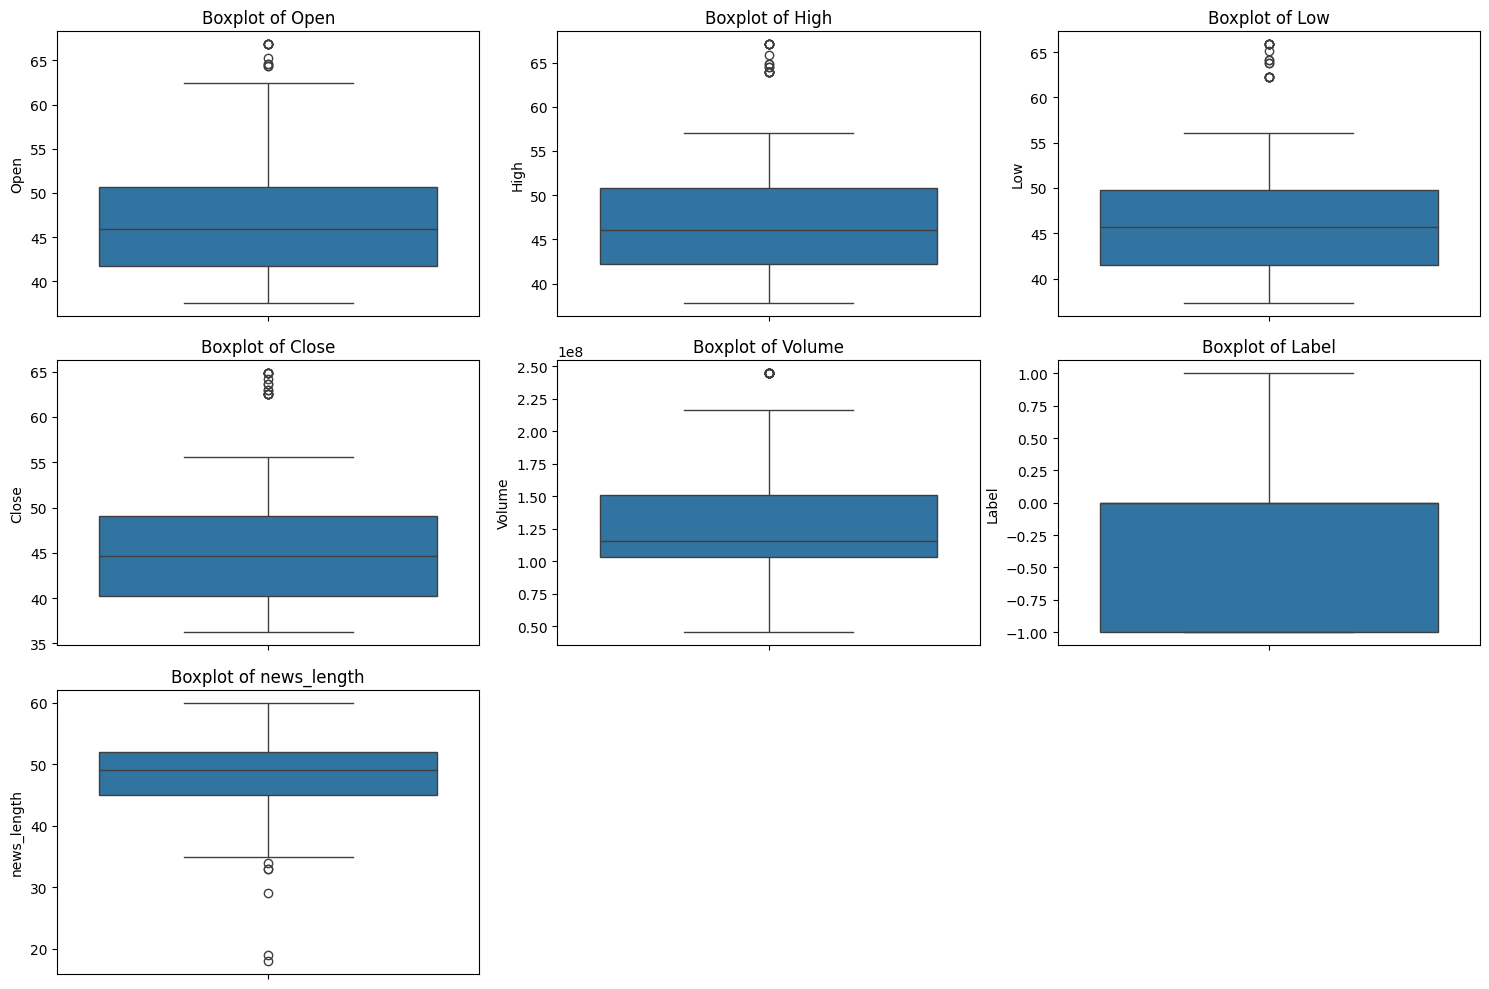

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

### The correlation matrix shows the relationship between all numeric variables in the dataset.

#### The Open, High, Low, and Close stock prices have a very strong positive correlation (close to 1.00), indicating that they move together.

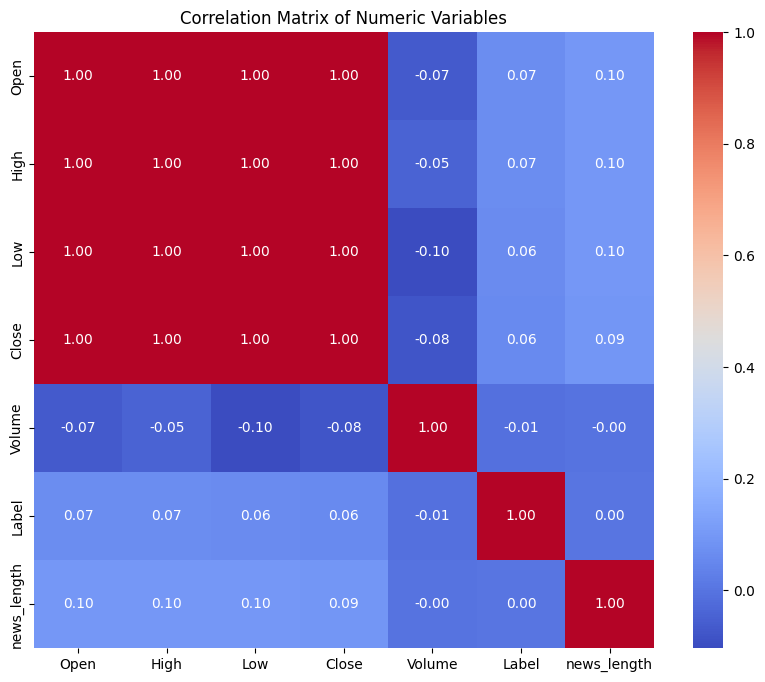

In [ ]:
correlation_matrix = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

### **Sentiment Polarity vs Price**

### This box plot compares stock prices across different sentiment categories.

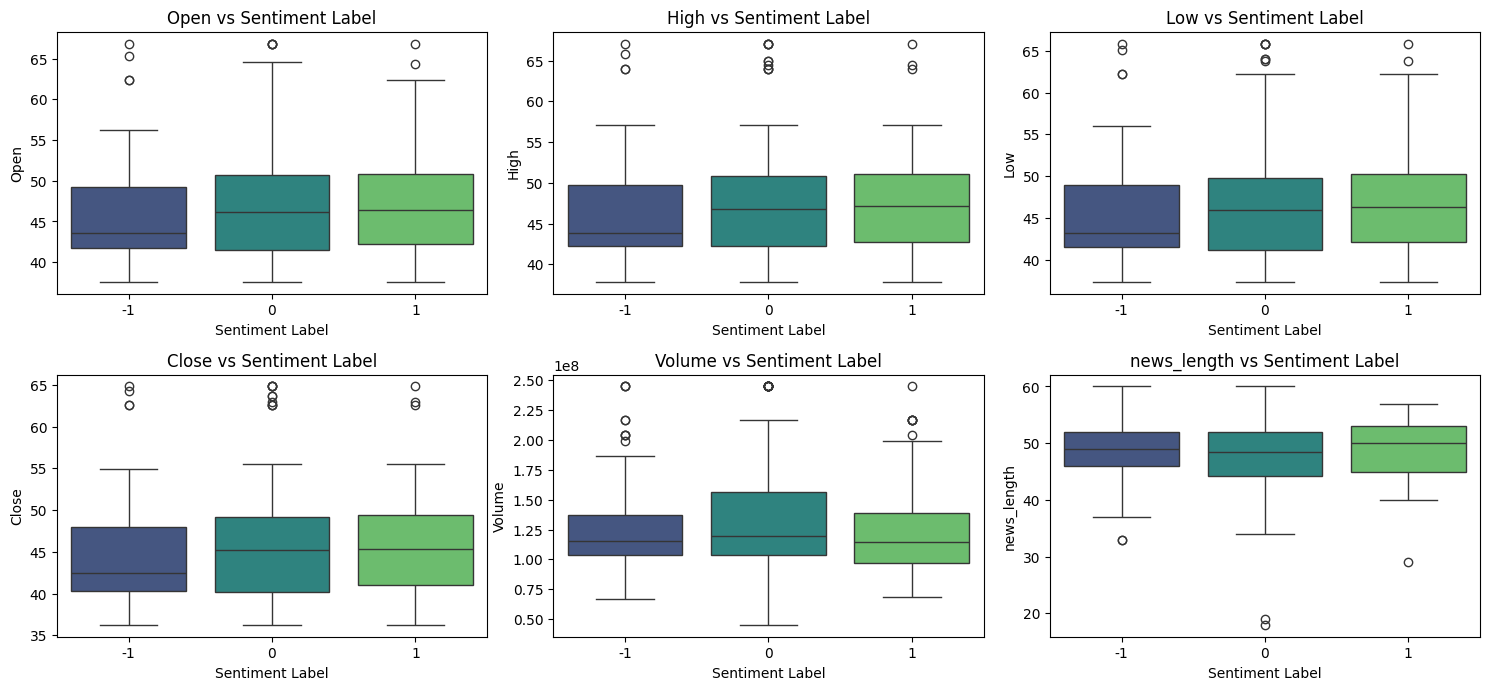

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.drop('Label', errors='ignore')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Label', y=col, data=data, palette='viridis')
    plt.title(f'{col} vs Sentiment Label')
    plt.xlabel('Sentiment Label')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

### The line chart shows how stock prices change over time. The Open, High, Low, and Close prices follow a similar trend throughout the period.


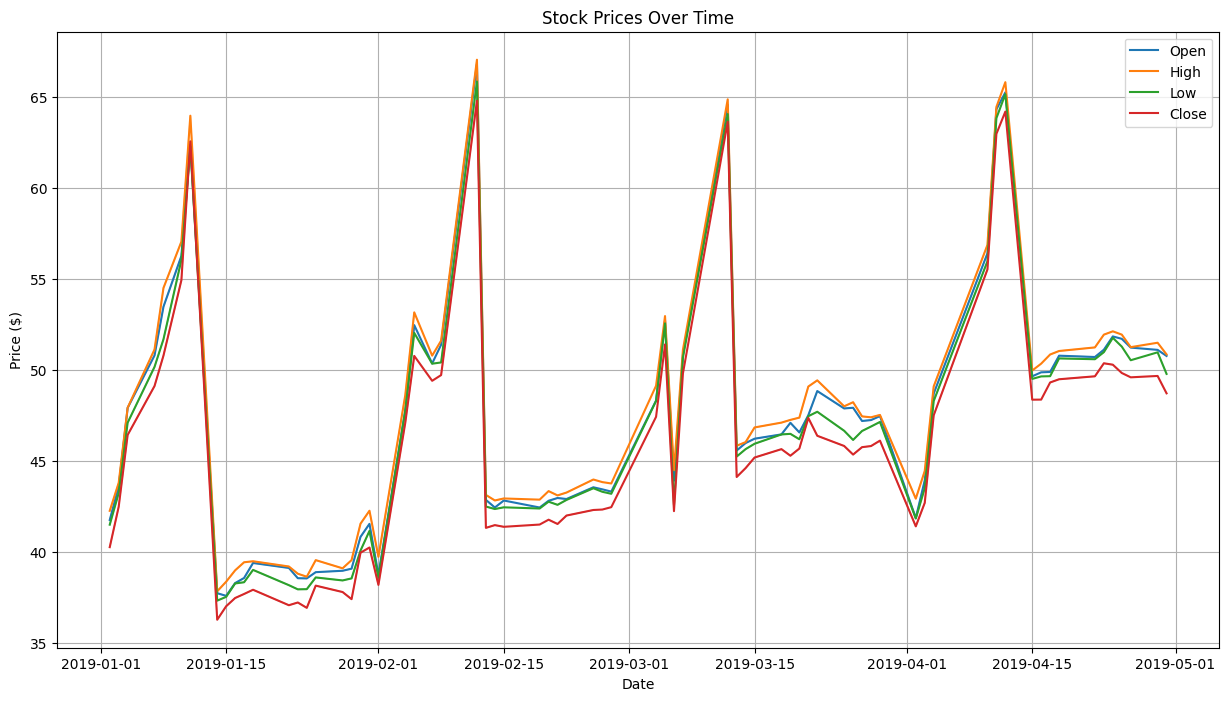

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='Date', y='Open', data=data, label='Open')
sns.lineplot(x='Date', y='High', data=data, label='High')
sns.lineplot(x='Date', y='Low', data=data, label='Low')
sns.lineplot(x='Date', y='Close', data=data, label='Close')

plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

### **Distribution of News Length Across Sentiment Categories**

### To compares the distribution of news article lengths across different sentiment categories.


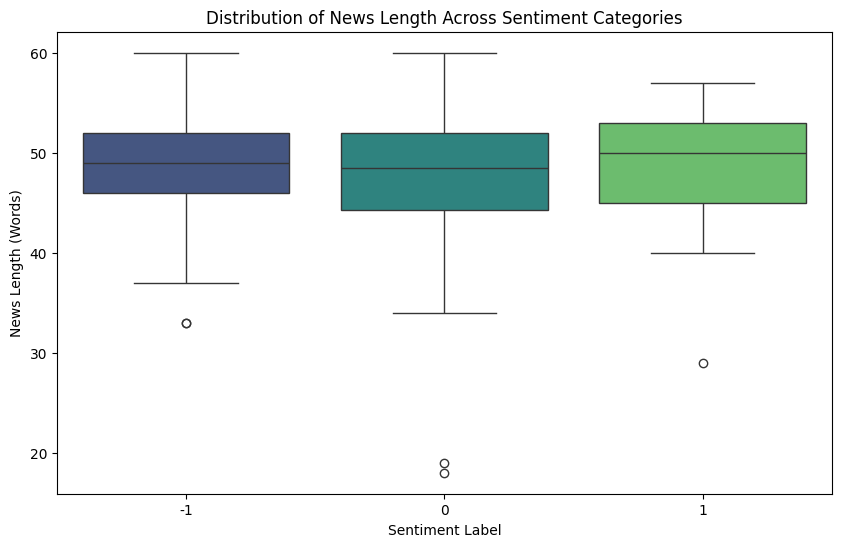

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='news_length', data=data, palette='viridis')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Label')
plt.ylabel('News Length (Words)')
plt.show()

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

* The news articles were converted into numerical vector representations using the Word2Vec model.

* Each word is represented as a 100-dimensional vector.

* The vectors of all words in a news article were averaged to create a single feature vector representing the entire article.

* These vectors capture semantic relationships between words and are used as input for sentiment classification.

### Creating a list of all words in our data

In [ ]:
words = [word for news in data['News'] for word in news.lower().split()]

### Training the Word2Vec model

In [ ]:
vec_size = 100
model = Word2Vec(sentences=[words], vector_size=vec_size, window=5, min_count=1, workers=4)

### Retrieving word vectors for all the words present in the model's vocabulary and Creating a dictionary of words and their corresponding vectors

In [ ]:
word_vectors = model.wv
word_vector_dict = {word: word_vectors[word] for word in word_vectors.index_to_key}

In [ ]:
def average_vectorizer_Word2Vec(doc):
    feature_vector = np.zeros((vec_size,), dtype="float64")
    words_in_vocab = [word for word in doc.split() if word in words]
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

### creating a dataframe of the vectorized documents

In [ ]:
X = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in data['News']])

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

* The BAAI/bge-base-en-v1.5 Sentence Transformer model was used to generate sentence embeddings.

* Each news article was converted into a 768-dimensional embedding vector.

* The embedding matrix has a shape of (349, 768), indicating 349 news articles with 768 features each.

* These embeddings preserve the contextual meaning of the news text and improve sentiment analysis performance.




In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

In [ ]:
embedding_matrix = model.encode(data['News'])

In [ ]:
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



## **Utility Functions**

### Confusion Matrix: The confusion matrix visualizes the model's prediction performance by comparing actual labels with predicted labels.

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(5, 4))

    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.title('Confusion Matrix')

    plt.show()

### Model Performance Metrics: The model is evaluated using Accuracy, Precision, Recall, and F1-Score to measure its overall classification performance.

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    acc = accuracy_score(actual,predicted)

    recall = recall_score(actual,predicted,average='weighted')

    precision = precision_score(actual,predicted,average='weighted')

    f1 = f1_score(actual,predicted,average='weighted')

    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

### The Word2Vec embeddings were used as input features for the Random Forest classifier.

In [ ]:
X = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in data['News']])


### The dataset was split into 80% training and 20% testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

### Building the model and fitting on train data

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Predicting on train data and test data

In [ ]:
y_pred_train = rf_model.predict(X_train)

y_pred_test = rf_model.predict(X_test)

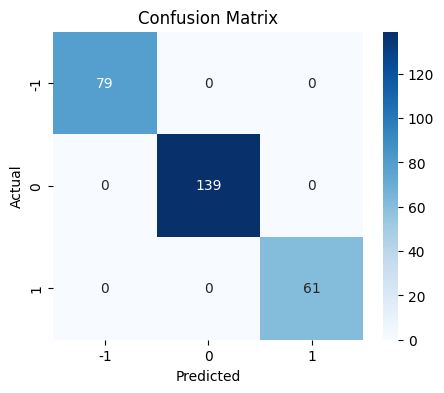

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

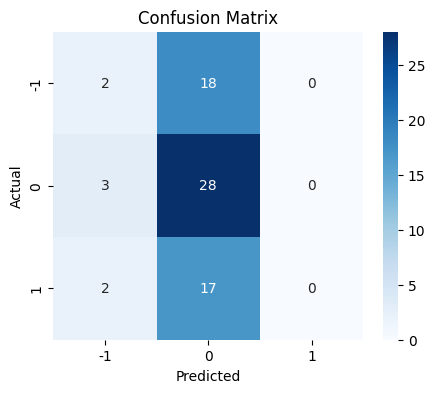

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

### The training metrics (Accuracy = 1.00, Precision = 1.00, Recall = 1.00, F1-score = 1.00) indicate perfect performance on the training data.

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.428571 0.428571   0.278458 0.306158


###**Sentence Transformer-Random Forest Model**

### Sentence Transformer embeddings were used as input to the Random Forest classifier.


In [ ]:
X = embedding_matrix


### Split data into training and testing set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Building the model and Fitting on train data

In [ ]:
rf_model_transformer = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Building the model and predicting on test data

In [ ]:
y_pred_train = rf_model_transformer.predict(X_train)

y_pred_test = rf_model_transformer.predict(X_test)

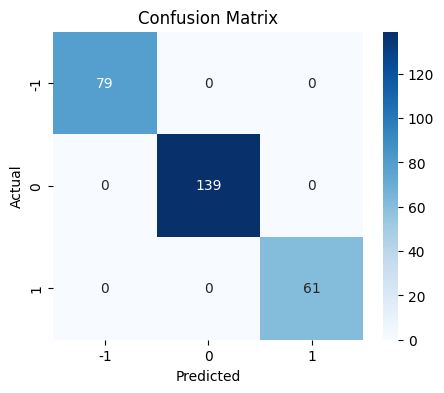

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

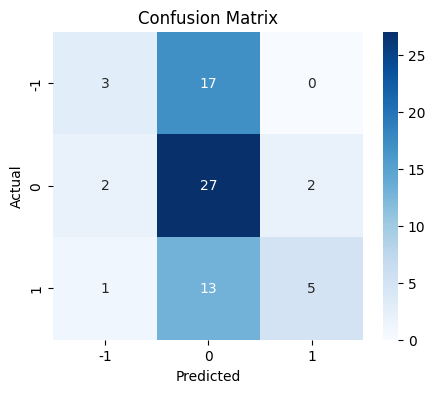

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

The testing confusion matrix shows improved classification compared to the Word2Vec Random Forest model.

Test Accuracy = 0.50 (50%)

Precision = 0.5465

Recall = 0.50

F1-score = 0.4421

The Sentence Transformer embeddings improved the Random Forest model's performance, although some misclassifications still remain.



In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

### A Neural Network model was created using Word2Vec embeddings.


In [ ]:
X = X

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

### The sentiment labels were converted from (-1, 0, 1) to (0, 1, 2) using a label map. This conversion makes the labels compatible with the Neural Network for multi-class classification.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

### A Neural Network architecture was created with two hidden layers and dropout for regularization. The model uses ReLU activation in the hidden layers and Softmax in the output layer to classify stock market news into three sentiment classes. Adam optimizer and Sparse Categorical Crossentropy were used for training.

In [ ]:
import gc

tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

### The model was trained for 20 epochs

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4803 - loss: 1.0589 - val_accuracy: 0.4429 - val_loss: 1.0655
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0224 - val_accuracy: 0.4429 - val_loss: 1.0638
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 1.0005 - val_accuracy: 0.4429 - val_loss: 1.0398
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 0.9665 - val_accuracy: 0.4429 - val_loss: 1.0136
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5197 - loss: 0.9294 - val_accuracy: 0.4714 - val_loss: 0.9998
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5161 - loss: 0.8926 - val_accuracy: 0.4714 - val_loss: 0.9812
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6022 - loss: 0.8689 - val_accuracy: 0.5714 - val_loss: 0.9464
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6272 - loss: 0.7992 - val_accuracy: 0.4857 - val_loss: 0.9605
Epoch

### Predict class probabilities on training data and Convert probabilities to class labels

In [ ]:
y_pred_prob_train = model.predict(X_train)
y_train_preds = np.argmax(y_pred_prob_train, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


### Predict class probabilities on training data and Convert probabilities to class labels

In [ ]:
y_pred_prob_test = model.predict(X_test)
y_test_preds = np.argmax(y_pred_prob_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


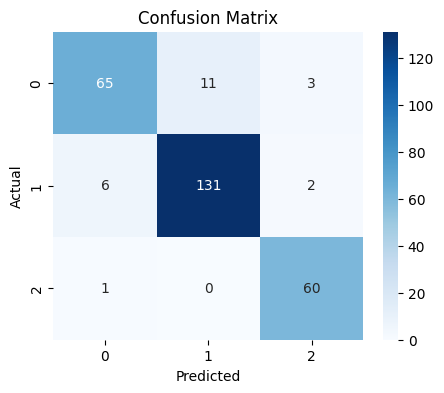

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

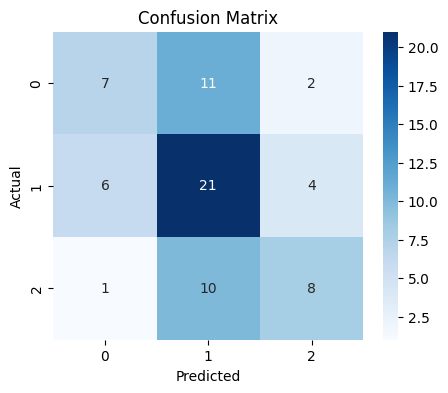

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

### The Neural Network performed very well on the training data but showed lower performance on the testing data. This suggests that the model learned the training patterns effectively but did not generalize equally well to new data. Further optimization can improve its performance on unseen data.

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.917563 0.917563   0.917059 0.916523
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.514286 0.514286   0.519388 0.504043


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

### Split data into training and testing set.

In [ ]:
X = embedding_matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

### The model summary confirms that the Neural Network architecture was built successfully with two hidden layers and one output layer. It contains 106,883 trainable parameters and is designed to classify stock market news into three sentiment categories.

In [ ]:
import gc

tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4982 - loss: 1.0723 - val_accuracy: 0.4429 - val_loss: 1.0632
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 1.0237 - val_accuracy: 0.4429 - val_loss: 1.0587
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4982 - loss: 0.9994 - val_accuracy: 0.4429 - val_loss: 1.0442
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4946 - loss: 0.9742 - val_accuracy: 0.4429 - val_loss: 1.0152
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5018 - loss: 0.9347 - val_accuracy: 0.4714 - val_loss: 0.9917
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5197 - loss: 0.8942 - val_accuracy: 0.4714 - val_loss: 0.9718
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5484 - loss: 0.8532 - val_accuracy: 0.4857 - val_loss: 0.9489
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5986 - loss: 0.8047 - val_accuracy: 0.5429 - val_loss: 0.9313
Epoc

### Predict class probabilities on training data and convert probabilities to class labels

In [ ]:
y_pred_prob_train = model.predict(X_train)

y_train_preds = np.argmax(y_pred_prob_train, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


### Predict class probabilities on test data and convert probabilities to class labels

In [ ]:
y_pred_prob_test = model.predict(X_test)

y_test_preds = np.argmax(y_pred_prob_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


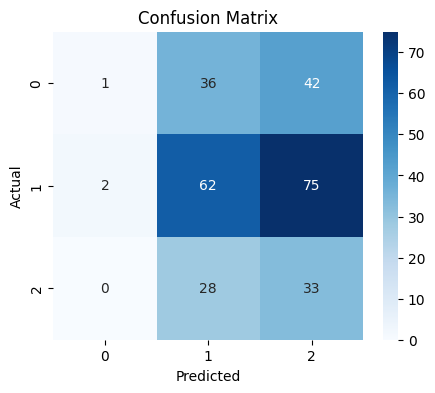

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

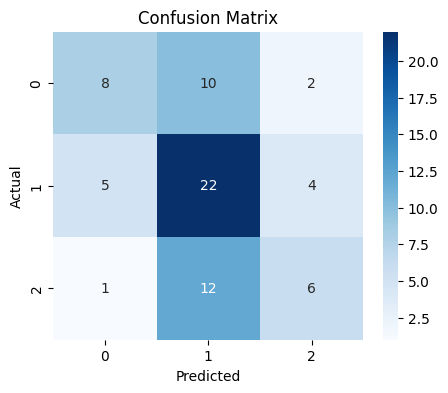

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

### The Neural Network performed well on the training data but showed reduced performance on the testing data. This suggests that while the model successfully learned the training patterns, additional tuning or more diverse data may improve its performance on new stock market news.

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision      F1
 0.913978 0.913978   0.915389 0.91281
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.514286 0.514286   0.520408 0.499332


### **Model Performance Summary and Final Model Selection**

### The performance of all models was summarized in a single table for comparison. Based on the evaluation metrics, the best-performing model was selected as the final model for predicting stock market news sentiment

In [ ]:
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,
        train_Word2Vec_NN.T,
        train_transformer_BAAI_RF.T,
        train_transformer_BAAI_NN.T
    ],
    axis=1  #
)

models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.917563,1.0,0.913978
Recall,1.0,0.917563,1.0,0.913978
Precision,1.0,0.917059,1.0,0.915389
F1,1.0,0.916523,1.0,0.912810


### The comparison results show that Neural Network models performed better than Random Forest models. Among all the models, Word2Vec + Neural Network achieved the best overall performance with the highest Accuracy and F1-score, making it the most suitable model for stock market news sentiment classification.

In [ ]:
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,
        test_Word2Vec_NN.T,
        test_transformer_BAAI_RF.T,
        test_transformer_BAAI_NN.T
    ],
    axis=1
)

models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.428571,0.514286,0.500000,0.514286
Recall,0.428571,0.514286,0.500000,0.514286
Precision,0.278458,0.519388,0.546509,0.520408
F1,0.306158,0.504043,0.442083,0.499332


## **Conclusions and Recommendations**

## **Conclusions**

## **Word2Vec:**
### Word2Vec successfully converted stock market news into numerical word embeddings, enabling the models to capture semantic relationships between words and perform sentiment classification.

## **Sentence Transformer Embeddings:**
### Sentence Transformer embeddings captured the contextual meaning of complete sentences, providing richer text representations and improving the understanding of stock market news.

## **Neural Networks:**
### Neural Network models achieved the best overall performance, showing higher Accuracy, Precision, Recall, and F1-score than Random Forest models. They were more effective at learning complex patterns in the data.

## **Random Forest:**
### Random Forest provided a strong baseline model but achieved lower performance than Neural Networks, indicating limited ability to capture complex relationships in text embeddings.

## **Recommendation**

* Increase the size and diversity of the training dataset to improve prediction accuracy.

* Apply additional text preprocessing techniques to reduce noise and improve data quality.

* Fine-tune the Sentence Transformer embedding model for better contextual representations.

* Explore advanced deep learning models such as BERT or larger Transformer architectures.

* Perform hyperparameter tuning and cross-validation to further improve the model's performance and generalization.

## **Final** **conclusion**

This project successfully developed a stock market news sentiment classification system using Word2Vec and Sentence Transformer embeddings with Random Forest and Neural Network models. After comparing all models, Word2Vec with Neural Network achieved the best overall performance and was selected as the final model. The project demonstrates that deep learning techniques can effectively classify stock market news sentiment and can support better financial decision-making.


<center><font size=7><b>Thank You</font></center>
